# 18.C21B Problem Set 4 Solutions

## Problem 1 (10+10 points)

In this problem you will experiment with the convergence of restarted GMRES(30) on $Ax=b$ (for a random $b$) on 1000x1000 matrices, using a pre-existing implementation such as those from pset 3, as you change the spectrum of the matrix.   For each part you will generate a plot of the relative residual $\Vert b - Ax \Vert / \Vert b \Vert$ of GMRES(30) as a function of the number of iterations.

**(a)** Plot (on a single labelled plot) the residual for the following four 1000x1000 matrices $A$ (diagonal is fine), and interpret your results:

* Half of the eigenvalues are $\lambda_k = 1 + \delta_k$ and half are $\lambda_k = 2 + \delta_k$, where $\delta_k$ is generated by `randn() * ε` where `ε = 1e-4`, i.e. two tight clusters around 1 and 2.
* Same thing, but `ε = 1e-2`
* The above two cases, but replace $A$ by $A - 0.95I$.

**(b)** Let $A = D + S$, where $D$ is the same diagonal matrix as in problem 2 of pset 3 (1000 eigenvalues logarithmically spaced from $10^{-2}$ to $10^3$, and $S$ is a random sparse matrix with small entries generated by [`sprand(1000,1000,1e-2) * 1e-2`](https://docs.julialang.org/en/v1/stdlib/SparseArrays/#SparseArrays.sprand) in Julia or [`scipy.sparse.random(1000,1000,1e-2) * 1e-2`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.random.html) in Python.   Plot the residual convergence of GMRES(30) for $Ax=b$ (you may need 1000s of iterations) and also $MAx = Mb$ where $M$ is a good preconditioner for this problem that is cheap to compute and effective at accelerating convergence.   Compute the sets of (complex) eigenvalues for $A$ and $MA$ (using `eigvals(Matrix(A))` in Julia or `eigvals(A.todense())` in Python) and plot them (in the complex plane) side-by-side (not in the same plot axes); does it correspond with what you saw of GMRES convergence?

### Solution

As in pset 3, rather than calling a library routine, we will implement this in Julia using the FNC book's simple implementation of  GMRES, modified to restart every $m$ iterations, so that you can see exactly what it is doing (though this implementation is rather inefficient).

In [1]:
using LinearAlgebra

function gmres(L, b, m; repeat=1)
    n = length(b)

    # Initial guess is zero.
    x = y = zero(b)
    resid = [1.0]
    r = b # residual b - Lx

    Q = zeros(n, m+1)
    H = zeros(m+1, m)

    for iter = 1:repeat # number of restarts
        Q[:, 1] = r / norm(r)
        for j in 1:m
            # Next step of Arnoldi iteration.
            v = L(Q[:, j]) # call the linear operator as a function
            for i in 1:j
                H[i, j] = dot(Q[:, i], v)
                v -= H[i, j] * Q[:, i]
            end
            H[j+1, j] = norm(v)
            Q[:, j+1] = v / H[j+1, j]
    
            # Solve the minimum residual problem.
            e = [norm(r); zeros(j)]
            z = H[1:j+1, 1:j] \ e
            y = Q[:, 1:j] * z
            push!(resid, norm(L(x + y) - b) / norm(b))
        end
        x += y # updated guess
        r = b - L(x) # updated residual
    end
    return x, resid
end
gmres(A::AbstractMatrix, b, m; repeat=1) = gmres(x -> A*x, b, m; repeat)

gmres (generic function with 2 methods)

In [2]:
m = 1000
b = randn(m);

**(a)** Here are the 4 test matrices for part (a), running GMRES(30) for $150 steps$ (5 restarts).

In [3]:
ε = 1e-4
A = Diagonal(randn(m) * ε + [fill(1, m÷2); fill(2, m÷2)])
_, resid1 = gmres(A, b, 30, repeat=5);
_, resid3 = gmres(A - 0.95I, b, 30, repeat=5);

ε = 1e-2
A = Diagonal(randn(m) * ε + [fill(1, m÷2); fill(2, m÷2)])
_, resid2 = gmres(A, b, 30, repeat=5);
_, resid4 = gmres(A - 0.95I, b, 30, repeat=5);

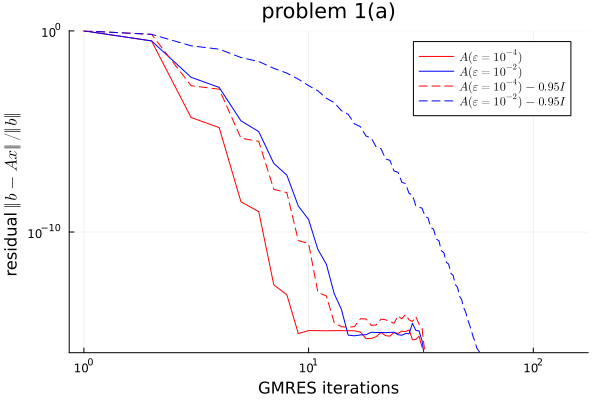

In [4]:
using Plots, LaTeXStrings

plot(resid1, label=L"A(\varepsilon = 10^{-4})", linecolor=:red)
plot!(resid2, label=L"A(\varepsilon = 10^{-2})", linecolor=:blue)
plot!(resid3, label=L"A(\varepsilon = 10^{-4}) - 0.95I", linecolor=:red, linestyle=:dash)
plot!(resid4, label=L"A(\varepsilon = 10^{-2}) - 0.95I", linecolor=:blue, linestyle=:dash)
plot!(xscale=:log10, yscale=:log10, ylim=(1e-16, 1), title="problem 1(a)",
      xlabel="GMRES iterations", ylabel=L"residual $\Vert b - Ax \Vert / \Vert b \Vert$", legend=:topright)

The results should not be unexpected:

* Smaller $\varepsilon$ corresponds to more clustered eigenvalues, and hence GMRES converges more quickly (red lines) vs. larger $\varepsilon$ (blue lines).
* subtracting $-0.95I$ makes the condition number $\approx 10\times$ larger (eigenvalues clustered around 0.05 and 1.05 instead of around 1 and 2), and hence makes the convergence (dashed lines) slower than without the shift (solid lines).

**(b)** Here is the diagonal + sparse test matrix.

In [5]:
using SparseArrays
D = Diagonal(exp10.(range(-2, 3, length=m)))
S = sprand(m,m,1e-2) * 1e-2
A = D + S

1000×1000 SparseMatrixCSC{Float64, Int64} with 10900 stored entries:
⎡⣽⣖⡷⣵⡿⢻⣽⣾⣹⣿⣪⣿⣶⢺⣿⣾⡝⣯⣿⡯⣧⣷⡗⣣⣨⣶⣿⣿⣶⣷⣷⡵⡾⣺⣫⣆⢻⡽⡷⠗⎤
⎢⢾⡫⠿⣾⣾⣺⣪⡿⣗⣛⣿⢿⣿⡷⣗⣾⢯⣾⣔⡼⣻⡽⢻⣿⢿⣶⣯⢿⣳⣹⣿⡾⣿⣷⠿⣽⢟⣷⢾⡷⎥
⎢⢰⣞⣿⣿⣿⣷⣿⡿⣾⣦⣿⣵⠿⡛⣞⣺⣿⢫⣏⣿⡭⡿⠿⢿⡵⡍⢶⣿⣿⣯⡏⣴⣻⣿⣾⢪⢓⣶⣵⠻⎥
⎢⢽⣒⠼⣧⣥⣯⣹⢝⡫⣭⡿⣼⣾⣾⡻⠿⣿⣿⣻⣿⣟⢿⡾⣖⠺⣿⣿⣯⣛⢽⣟⢏⣳⢯⣾⣿⡿⣑⣽⣗⎥
⎢⣹⣮⣣⣿⣟⢊⣂⣶⣻⢯⣾⣿⢶⢽⣟⣞⢿⢹⣞⡾⡗⢚⡷⡟⡽⣮⣿⣹⡻⣾⣿⣛⢻⡿⡭⣮⣿⣾⣯⡎⎥
⎢⢾⢯⢿⣲⣽⡽⣷⣟⢝⡟⣿⣷⢮⡓⣩⣯⣝⣽⣿⣛⣿⣯⡏⣧⢟⣯⣌⢙⣿⢿⣟⣽⣶⣿⣯⣿⠿⣫⣽⡗⎥
⎢⣜⣫⣽⢟⣽⣿⡿⢹⣷⣼⣼⣽⣻⢦⣬⣦⣪⣷⣿⣿⣮⣶⡯⡿⢏⣼⣝⡻⡦⣿⣿⣖⡿⣿⣿⣿⣟⣗⣵⣿⎥
⎢⢺⣾⡽⣯⢿⣾⣿⣾⣛⣷⢷⢿⣛⢫⡕⣿⢭⣷⣾⣿⢾⡽⢼⣚⢏⣿⣟⣻⠽⣾⣿⣯⣯⣿⣻⡁⡿⣰⣵⠽⎥
⎢⠵⢿⡷⣫⣮⡷⣟⣟⢺⡽⡾⣿⣧⣿⡿⣗⡿⢯⣗⢟⢷⣷⣩⣖⣿⣫⣽⣯⡟⣿⠻⢵⣯⢇⣿⣷⣻⢹⠷⣓⎥
⎢⡜⣟⡷⢏⡳⣿⣕⣯⣿⣛⣽⣘⣗⢟⡟⣇⣍⢿⢟⢿⣿⣗⣯⣻⢿⣯⣿⡟⣮⣹⡷⣇⢿⢾⣿⣹⣟⣷⣗⡗⎥
⎢⢺⣽⣄⣟⣛⣷⢴⠻⢭⣿⣷⢞⣜⣾⣿⢶⢿⣉⣯⣿⢟⢯⣷⣽⣭⡺⢛⣮⣞⢿⣮⣳⣯⢟⣷⡩⣿⣕⣿⡧⎥
⎢⣸⣾⣯⡋⣿⣟⣍⣶⢷⡶⣳⣶⣿⢾⣿⣵⢝⣷⣶⣎⣗⣿⣗⣮⣯⡾⣽⢿⣵⣞⡽⠲⣿⣻⡯⣿⣷⣹⣟⡦⎥
⎢⢻⣽⣍⣿⡾⠿⣷⣾⣿⡼⣶⣻⣟⣷⣽⢿⣿⣿⣻⣯⡾⢾⡿⣿⡿⣦⣻⣟⣿⠯⣿⣫⣿⣽⡿⡵⢴⢹⣻⣝⎥
⎢⢸⢸⢶⡿⣞⢰⡿⢯⣋⣻⣿⣗⣾⢽⢰⣳⣕⡻⡿⣼⣿⣾⡿⣟⢿⣿⢗⢝⣤⣼⢿⠻⣟⣏⡓⢿⢬⣷⢇⡗⎥
⎢⡽⡿⣞⣶⣛⣻⣧⣿⣼⣷⣻⣯⣿⣯⢯⡽⣿⣿⣿⣿⣿⣾⣲⣒⣩⣿⣿⣿⣻⢾⢿⣺⣿⣽⢼⣟⣿⡾⢿⢕⎥
⎢⣾⡯⣯⣻⡟⣾⣯⣿⢬⣋⣿⠾⣗⢾⣹⠿⢟⣹⣟⣿⣿⡟⣩⡽⣎⣯⣯⣿⣮⣍⣟⣷⡯⡟⣭⡿⣽⣖⡿⣅⎥
⎢⠺⣷⢻⣺⣎⣎⢋⢷⡻⠷⣿⠿⢟⣮⢑⢯⡼⣷⣧⣵⣳⣙⣿⢯⢷⣯⣺⡗⣿⣾⣏⣺⣿⢵⡽⢿⣻⢿⢿⣊⎥
⎢⢩⣿⣻⣶⣽⣵⣾⣿⣾⣼⢫⣬⣯⡿⣺⣿⣶⡾⣴⡽⣯⣻⢽⣛⠿⣾⢿⣟⡿⡽⢿⣛⢱⣯⣿⣿⢟⢫⣽⡟⎥
⎢⣾⣿⣻⡦⣿⣽⣱⣷⢾⢿⣛⢿⣿⡓⣾⣾⡿⠝⣳⡿⡿⣴⣾⡍⣻⣬⡿⡿⣷⢞⣯⣏⣷⣿⢝⣯⡿⢿⣷⣏⎥
⎣⣶⢛⣼⡯⣻⠿⣭⢛⡿⣍⢜⠞⠻⡻⡿⣣⣵⡿⡾⢻⠺⠟⡿⣋⢦⠿⡽⢿⢿⡪⢷⣸⢿⡧⡳⣿⣽⣿⡽⣇⎦

What preconditioner should we use?  An obvious choice here is a diagonal "Jacobi" preconditioner, since the diagonal entries of $D$ are mostly much larger than the entries of $A$, and hence $\Vert D \Vert \gg \Vert S \Vert$:

In [6]:
@show norm(D)
@show norm(S);

norm(D) = 6624.797314823461
norm(S) = 0.5766767244595947


So, we can simply left-precondition by the inverse of the diagonal parts of $A$, or even more simply by $D^{-1}$.  i.e. solve $D^{-1} A x = D^{-1} b$ (left precondition).  Our `gmres` function above doesn't take a separate preconditioner argument, but we can simply pass in the modified linear system.

`inv(D)` in Julia is efficient because `D` is the special `Diagonal` type, so it knows that it can simply invert the diagonal entries.  And since it is sparse we can simply compute the sparse matrix $D^{-1} A$ explicitly for simplicity, though in practice we would typically pass $D^{-1}$ as a separate "preconditioner" operator to a library routine.

Without preconditioning, GMRES(30) will converge quite slowly, so we'll run it for 4000 restarts to get a good plot.

In [7]:
_, resid = gmres(A, b, 30, repeat=4000);
_, resid_pre = gmres(inv(D) * A, inv(D) * b, 30, repeat=20);

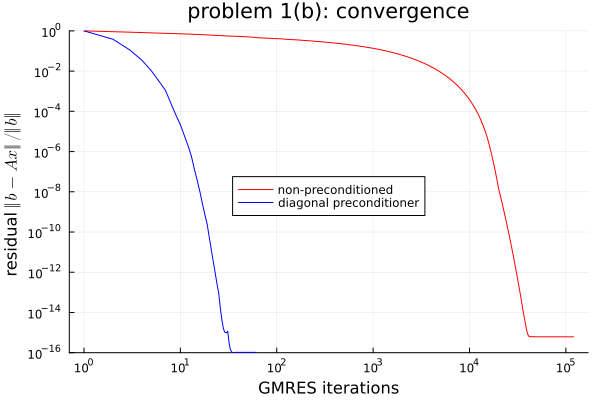

In [8]:
plot(resid, linecolor=:red, label="non-preconditioned")
plot!(resid_pre, linecolor=:blue, label="diagonal preconditioner")
plot!(xscale=:log10, yscale=:log10, ylim=(1e-16, 1), title="problem 1(b): convergence", 
      xlabel="GMRES iterations", ylabel=L"residual $\Vert b - Ax \Vert / \Vert b \Vert$", legend=:inside,
      xticks=exp10.(0:6), yticks=exp10.(-16:2:0))

As we hoped, the preconditioner makes convergence **much** faster, in fact **orders of magnitude faster**.

This is also reflected in the eigenvalue spectra: the eigenvalues are spread out over 5 orders of magnitude for $A$, but are clustered around $|\lambda - 1| \lesssim 0.4$ for $D^{-1}A$:

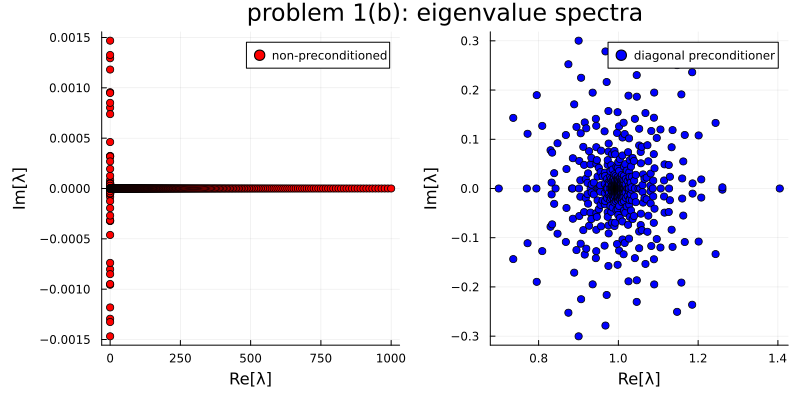

In [9]:
λ = eigvals(Matrix(A))
λpre = eigvals(Matrix(inv(D) * A));
p1 = scatter(real(λ), imag(λ), markercolor=:red, label="non-preconditioned", xlabel="Re[λ]", ylabel="Im[λ]")
p2 = scatter(real(λpre), imag(λpre), markercolor=:blue, label="diagonal preconditioner", xlabel="Re[λ]", ylabel="Im[λ]")
plot(p1, p2, layout=(1, 2), size=(800,400), plot_title="problem 1(b): eigenvalue spectra",
     left_margin=5Plots.mm, bottom_margin=5Plots.mm)

## Problem 2 (10 points)

For problem 2 of pset 2, explain why you can evaluate your polynomials $p_k(x)$ (of degree $k-1$) at any desired $x$ recursively using a 3-term recurrence: $p_{k}(x) = (a_k x + c_k) p_{k-1}(x) + b_k p_{k-2}(x)$, explain how to compute the coefficients $a_k,b_k,c_k$ as a byproduct of the Arnoldi algorithm, and give the starting polynomials $p_1(x)$ and $p_2(x)$.

### Solution

In pset 2, you showed that these $p_k$ exactly corresponded to the orthonormal vectors produced by the Arnoldi process applied to the operator `A = Diagonal(x)` and starting with the vector of all 1's.   But this matrix is real-symmetric, and we showed in class that Arnoldi applied to a symmetric matrix simplies to the Lanczos algorithm, in which $A Q_n = Q_n T_n + h_{n+1,n} q_{n+1} e_n^T$, where $T_n$ is a symmetric tridiagonal matrix (a special case $T_n = H_n$ of the upper-Hessenberg matrix $H_n$ of Arnoldi, whose entries are simply dot products from the Arnoldi algorithm).

If we look at the $k$-th column, this tridiagonal formula for $A Q_n$ corresponds to $A q_k = h_{k-1,k} q_{k-1} + h_{k,k} q_k + h_{k+1,k} q_{k+1}$.    But we saw in pset 2 that exactly the same linear combinations are used to construct the polnomials $p_k$ from the prevous polynomials, and hence (replacing $A$ by $x$):

$$
p_{k+1}(x) = \frac{1}{h_{k+1,k}} \left[ x p_k(x) - h_{k-1,k} p_{k-1}(x) - h_{k,k} p_k(x)\right] 
$$

or equivalently (replacing $k$ with $k-1$).

$$
p_{k}(x) = \frac{1}{h_{k,k-1}} \left[ x p_{k-1}(x) - h_{k-1,k} p_{k-2}(x) - h_{k,k} p_{k-1}(x)\right] 
$$

So, by inspection $\boxed{a_k = 1/h_{k,k-1},c_k = - h_{k,k}/h_{k,k-1}, \text{ and } b_k = - h_{k-1,k}/h_{k,k-1}}$.

To start out the recurrence, the first polynomial is just the monomial $1$ normalized using our discrete $m$-point inner product: $\boxed{p_1(x) = 1/\sqrt{m}}$.   The second polynomial is $x p_1(x)$ projected orthogonal to $p_1(x)$ and normalized.   Without normalizing, this is:
$$
v_2(x) = x p_1(x) - p_1(x) \langle p_1, x p_1 \rangle = \frac{1}{\sqrt{m}} \left[ x - \frac{1}{m} \sum_{j=1}^m x_j \right]
$$
which is simply taking $x$ and subtracting the mean of all the sample points $x_j$.  Our $p_2(x)$ is then computed by normalizing this in our discrete inner product:
$$
\boxed{p_2(x) = \frac{v_2(x)}{\sqrt{\sum_{j=1}^m v_2(x_j)^2}}}
$$

## Problem 3 (5 + 10 points)

**(a)** If you want to solve $Ax = b$ for an arbitrary invertible $m \times m$ matrix, you can equivalently multiply both sides by $A^T$ and solve $A^T A x = A^T b$.   This has the advantage that $A^T A$ is SPD, so you can use the steepest-descent or (much better) the conjugate-gradient algorithm (no need for restarted GMRES!).  Explain why this may be a bad idea, even though it theoretically converges for any $A$.

**(b)** Try out this strategy with a matrix $A + 0.1I$ where $A$ is the matrix from problem 1(b): compare the convergence of the residual for GMRES(30) on $Ax=b$ with conjugate-gradient (CG) on $A^T A x = A^T b$, both without preconditioning.  You can use a library implementation of CG, such as [`scipy.sparse.linalg.cg`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.cg.html) in Python or [`Krylov.cg`](https://jso.dev/Krylov.jl/stable/solvers/spd/#Krylov.cg) in Julia.

### Solution

**(a)** The problem with this, as we saw in 18.C21, is that $\kappa(A^T A) = \kappa(A)^2$: we have squared the condition number.  Unless $A$ is very well conditioned (which unfortunately doesn't happen that often unless you have a great precondititioner … in which case GMRES will work fine too), this will enormously slow down convergence *and* will make the resulting solution less accurate in the face of roundoff (or other) errors.

(This algorithm is known as **CGNE**: conjugate gradient on the normal equations.)

**(b)** Let's try it out numerically with the suggested matrix, using the Julia Krylov.jl package for a conjugate-gradient solver.

We'll also compute the condition number (which was not required) — we find that $\kappa(A) \approx 10^4$, so we would expect that squaring it will slow things down by orders of magnitude.

In [10]:
using SparseArrays, LinearAlgebra
D = Diagonal(exp10.(range(-2, 3, length=m)))
S = sprand(m,m,1e-2) * 1e-2
A = 0.1I + D + S

@show cond(Matrix(A)) # convert to a dense matrix and compute the condition number

_, resid = gmres(A, b, 30, repeat=400);

cond(Matrix(A)) = 9627.758881619977


In [11]:
import Krylov

_, stats = Krylov.cg(A'A, A'b, rtol=0.0, itmax=10^7, history=true)
stats

SimpleStats
 niter: 62352
 solved: true
 inconsistent: false
 indefinite: false
 npcCount: 0
 residuals: [ 7.0e+03  3.8e+03  2.9e+03 ...  1.7e-08  2.0e-08  1.5e-08 ]
 Aresiduals: []
 κ₂(A): []
 allocation timer: 1.92μs
 timer: 2.48s
 status: solution good enough given atol and rtol


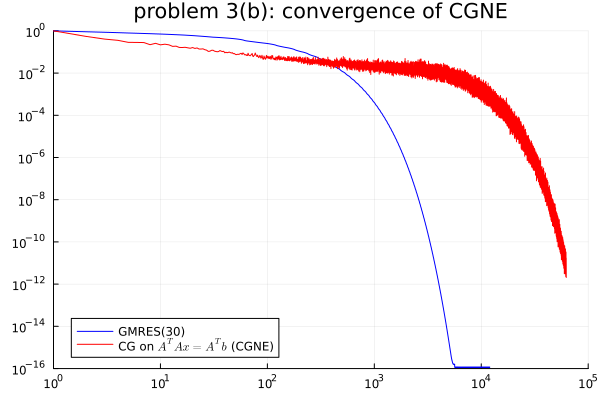

In [12]:
using Plots
plot(resid, color=:blue, label="GMRES(30)")
plot!(stats.residuals / norm(A'b), color=:red, label=L"CG on $A^T Ax = A^T b$ (CGNE)")
plot!(xscale=:log10, yscale=:log10, ylim=(1e-16, 1), xlim=(1,10^5), xticks=exp10.(0:5), yticks=exp10.(-16:2:0),
      title="problem 3(b): convergence of CGNE", legend=:bottomleft)